# Build a model to classify restaurant popularity (Low/Medium/High) from operational and customer data.

# import Library

In [154]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [155]:
data = pd.read_csv('restaurant_dataset.csv')

# Check rows and columns

In [156]:
data.shape

(3392, 10)

In [157]:
data.head()

,Location,Average_Cost,Online_Order,Table_Booking,Rating,Votes,Reviews_Count,Cuisines,Delivery_Time,Popularity
0,Indore,227.0,Yes,Yes,3.2,586,438.0,Continental,36,Low
1,Delhi,237.0,No,No,2.9,61,67.0,Rajasthani,49,Low
2,Mumbai,125.0,No,Yes,3.3,299,109.0,Cafe,28,Low
3,Surat,152.0,Yes,Yes,2.7,532,482.0,Kerala,26,High
4,Ahmedabad,151.0,No,No,3.3,377,510.0,Cafe,36,Low


In [158]:
data.tail()

,Location,Average_Cost,Online_Order,Table_Booking,Rating,Votes,Reviews_Count,Cuisines,Delivery_Time,Popularity
3387,Ahmedabad,222.0,No,No,3.3,101,141.0,South Indian,22,Low
3388,Kochi,143.0,Yes,Yes,3.5,703,500.0,Biryani,26,Low
3389,Bhopal,86.0,No,Yes,3.0,1521,473.0,Street Food,41,Low
3390,Jaipur,97.0,No,Yes,2.8,821,58.0,Cafe,47,Low
3391,Hyderabad,401.0,No,No,4.4,664,101.0,Biryani,23,High


In [159]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3392 entries, 0 to 3391
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Location       3392 non-null   object 
 1   Average_Cost   3275 non-null   float64
 2   Online_Order   3392 non-null   object 
 3   Table_Booking  3392 non-null   object 
 4   Rating         3250 non-null   float64
 5   Votes          3392 non-null   int64  
 6   Reviews_Count  3267 non-null   float64
 7   Cuisines       3392 non-null   object 
 8   Delivery_Time  3392 non-null   int64  
 9   Popularity     3392 non-null   object 
dtypes: float64(3), int64(2), object(5)
memory usage: 265.1+ KB


## Drop unwanted Features

In [160]:
data.drop(['Online_Order', 'Table_Booking', 'Cuisines'], inplace=True, axis=1)

# Perform EDA

## Handle Null values

In [161]:
data.isnull().sum()

Location           0
Average_Cost     117
Rating           142
Votes              0
Reviews_Count    125
Delivery_Time      0
Popularity         0
dtype: int64

In [162]:
data['Average_Cost'] = data['Average_Cost'].fillna(data['Average_Cost'].mean())
data['Rating'] = data['Rating'].fillna(data['Rating'].mean())
data['Reviews_Count'] = data['Reviews_Count'].fillna(data['Reviews_Count'].mean())

In [163]:
data.isnull().sum()

Location         0
Average_Cost     0
Rating           0
Votes            0
Reviews_Count    0
Delivery_Time    0
Popularity       0
dtype: int64

In [164]:
data['Votes'] = data['Votes'].astype(float)
data["Delivery_Time"] = data["Delivery_Time"].astype(float)

# check outliers

In [165]:
import matplotlib.pyplot as plt
import seaborn as sns

def checkOutliers(data, col):
    plt.figure(figsize=(12,4))
    
    # Boxplot
    plt.subplot(1,2,1)
    plt.boxplot(data[col])
    plt.title(f"Boxplot of {col}")
    
    # Histogram 
    plt.subplot(1,2,2)
    sns.histplot(data=data, x=col, kde=True)
    
    mean = data[col].mean()
    std = data[col].std()
    
    plt.axvline(mean + 3*std, color='red')
    plt.axvline(mean - 3*std, color='red')
    
    plt.tight_layout()
    plt.show()

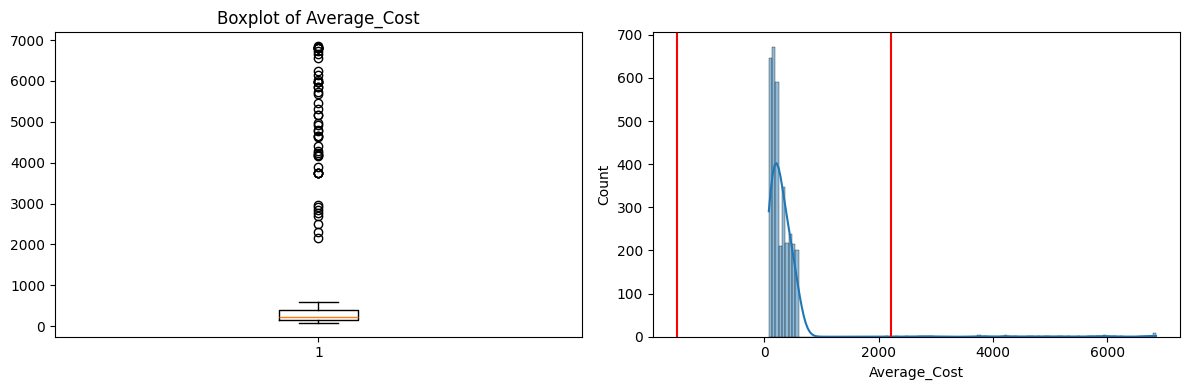

In [166]:
checkOutliers(data, 'Average_Cost')

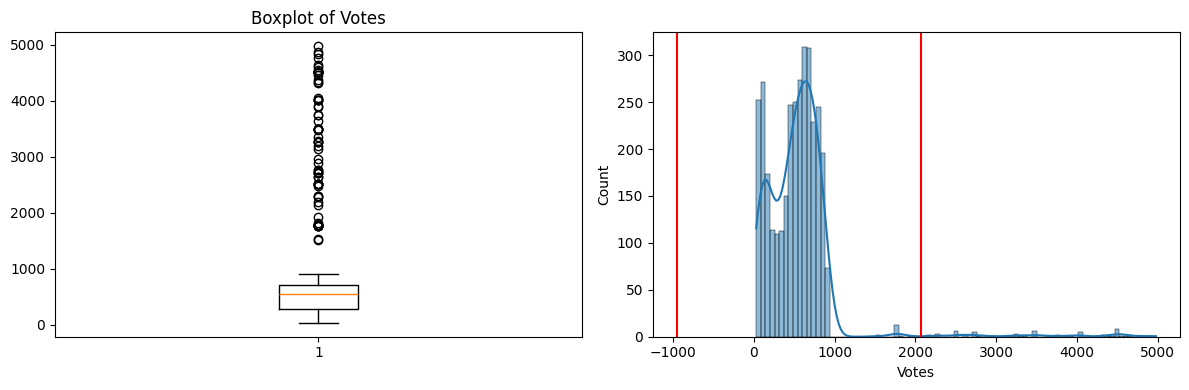

In [167]:
checkOutliers(data, 'Votes')

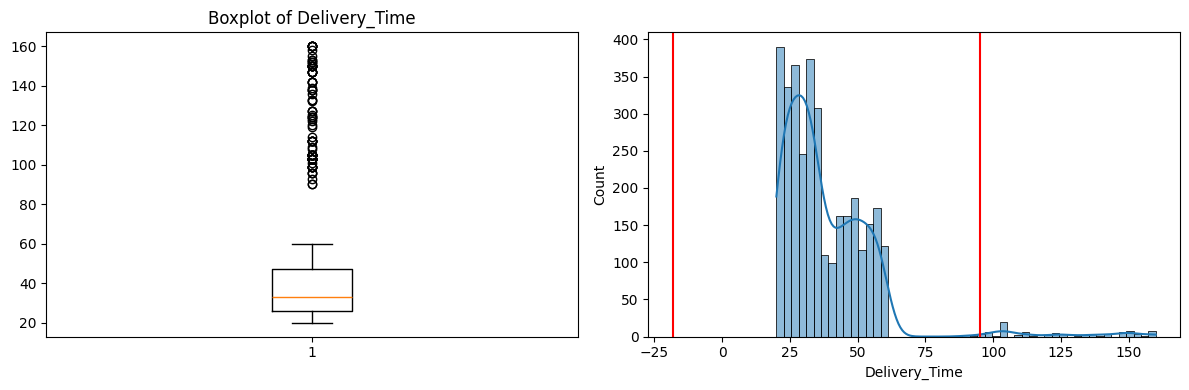

In [168]:
checkOutliers(data, 'Delivery_Time')

# Handle Outliers

In [169]:
def handleOuteliers(data, col):
    Q3 = data[col].quantile(0.75)
    Q1 = data[col].quantile(0.25)
    
    IQR = Q3 - Q1
    
    upper = Q3 + (1.5 * IQR)
    lower = Q1 - (1.5 * IQR)
    
    data.loc[data[col] > upper, col] = upper
    data.loc[data[col] < lower, col] = lower

In [170]:
handleOuteliers(data, 'Average_Cost')
handleOuteliers(data, 'Votes')
handleOuteliers(data, 'Delivery_Time')

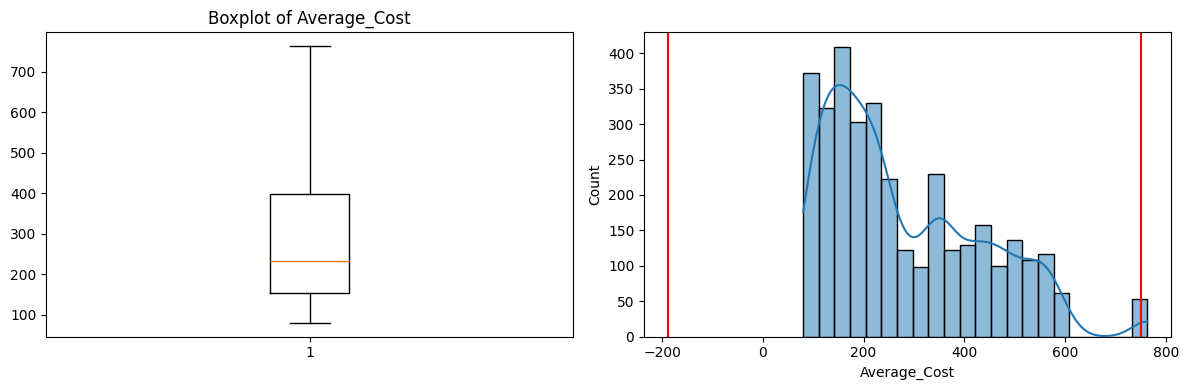

In [171]:
checkOutliers(data, 'Average_Cost')

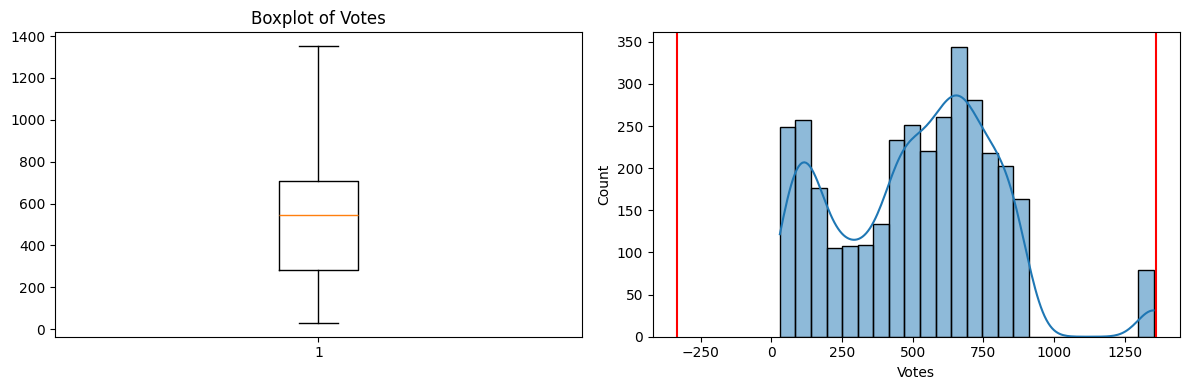

In [172]:
checkOutliers(data, 'Votes')

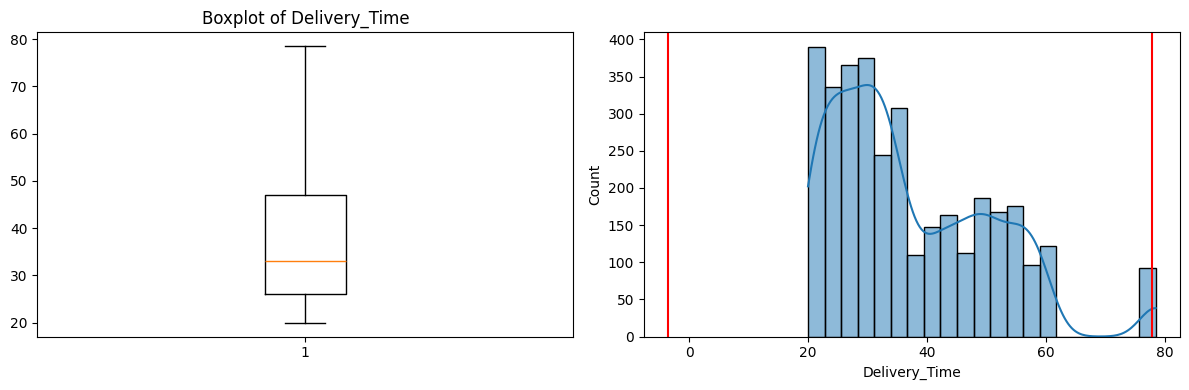

In [173]:
checkOutliers(data, 'Delivery_Time')

# Encoding

In [174]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

cols = ['Location']

for col in cols:
    data[col] = le.fit_transform(data[col].astype(str))

In [175]:
data.head()

,Location,Average_Cost,Rating,Votes,Reviews_Count,Delivery_Time,Popularity
0,7,227.0,3.2,586.0,438.0,36.0,Low
1,4,237.0,2.9,61.0,67.0,49.0,Low
2,10,125.0,3.3,299.0,109.0,28.0,Low
3,14,152.0,2.7,532.0,482.0,26.0,High
4,0,151.0,3.3,377.0,510.0,36.0,Low


In [176]:
# plt.figure(figsize=(30, 10))
# sns.heatmap(data.corr(), annot=True)
# plt.show()

In [177]:
data['Popularity'].value_counts()

Popularity
Low     1696
High    1696
Name: count, dtype: int64

# Random Forest

In [178]:
X = data.drop(['Popularity'], axis=1)
y = data['Popularity']

In [179]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [180]:
from sklearn.ensemble import RandomForestClassifier

In [181]:
RF = RandomForestClassifier()
RF.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [182]:
train_pred = RF.predict(X_train)
test_pred = RF.predict(X_test)

In [183]:
from sklearn.metrics import accuracy_score

In [184]:
print('Training Accuracy: ', accuracy_score(y_train, train_pred))
print('Testing Accuracy: ', accuracy_score(y_test, test_pred))

Training Accuracy:  1.0
Testing Accuracy:  0.9862475442043221


In [185]:
from sklearn.metrics import classification_report, confusion_matrix

In [186]:
# Training Accuracy
# train_predict = dt.predict(X_train)
print(classification_report(y_train, train_pred))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1199
         Low       1.00      1.00      1.00      1175

    accuracy                           1.00      2374
   macro avg       1.00      1.00      1.00      2374
weighted avg       1.00      1.00      1.00      2374



In [187]:
# Testing Accuracy
# test_predict = dt.predict(X_test)
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

        High       0.98      0.99      0.99       497
         Low       0.99      0.98      0.99       521

    accuracy                           0.99      1018
   macro avg       0.99      0.99      0.99      1018
weighted avg       0.99      0.99      0.99      1018



In [188]:
X.head()

,Location,Average_Cost,Rating,Votes,Reviews_Count,Delivery_Time
0,7,227.0,3.2,586.0,438.0,36.0
1,4,237.0,2.9,61.0,67.0,49.0
2,10,125.0,3.3,299.0,109.0,28.0
3,14,152.0,2.7,532.0,482.0,26.0
4,0,151.0,3.3,377.0,510.0,36.0


In [189]:
import streamlit as st
import pickle
# import joblib

In [130]:
with open("model.pkl", "wb") as file:
    pickle.dump(RF, file)

In [131]:
# # LOW
# Average Cost: 150
# Rating: 2.8
# Votes: 80
# Delivery Time: 50
# Reviews Count: 40
# Cuisine Encoded: 2

In [133]:
# # HIGH
# Average Cost: 600
# Rating: 4.4
# Votes: 900
# Delivery Time: 25
# Reviews Count: 500
# Cuisine Encoded: 8